In [ ]:
from google.colab import drive
drive.mount('/content/drive')
!gdown --fuzzy "https://drive.google.com/file/d/1Ox7sCEqtM7gOM8Y72H1bqHULtWolfTu3/view?usp=sharing"

Mounted at /content/drive
Downloading...
From (original): https://drive.google.com/uc?id=1Ox7sCEqtM7gOM8Y72H1bqHULtWolfTu3
From (redirected): https://drive.google.com/uc?id=1Ox7sCEqtM7gOM8Y72H1bqHULtWolfTu3&confirm=t&uuid=6cec042a-1ba6-47e4-9c78-b46b27458f3d
To: /content/final-clean-data.zip
100% 2.28G/2.28G [00:20<00:00, 111MB/s]


In [26]:
import torch, gc
gc.collect()
torch.cuda.empty_cache()
torch.cuda.ipc_collect()

In [ ]:
!unzip "/content/final-clean-data.zip" -d "/content/dataset"

Archive:  /content/final-clean-data.zip
   creating: /content/dataset/final-clean-data/
   creating: /content/dataset/final-clean-data/T1/
  inflating: /content/dataset/final-clean-data/T1/BraTS20_Training_001_t1.nii  
  inflating: /content/dataset/final-clean-data/T1/BraTS20_Training_002_t1.nii  
  inflating: /content/dataset/final-clean-data/T1/BraTS20_Training_003_t1.nii  
  inflating: /content/dataset/final-clean-data/T1/BraTS20_Training_004_t1.nii  
  inflating: /content/dataset/final-clean-data/T1/BraTS20_Training_005_t1.nii  
  inflating: /content/dataset/final-clean-data/T1/BraTS20_Training_006_t1.nii  
  inflating: /content/dataset/final-clean-data/T1/BraTS20_Training_007_t1.nii  
  inflating: /content/dataset/final-clean-data/T1/BraTS20_Training_008_t1.nii  
  inflating: /content/dataset/final-clean-data/T1/BraTS20_Training_009_t1.nii  
  inflating: /content/dataset/final-clean-data/T1/BraTS20_Training_010_t1.nii  
  inflating: /content/dataset/final-clean-data/T1/BraTS20_Tra

In [ ]:
!pip install -q monai nibabel matplotlib tqdm
!pip install -q "monai-generative"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 46.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.2/176.2 kB 8.4 MB/s eta 0:00:00


In [25]:
import gc
gc.collect()


0

In [ ]:
import os
import random
from pathlib import Path

import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader

from monai.transforms import (
    Compose,
    LoadImaged,
    EnsureChannelFirstd,
    Orientationd,
    Spacingd,
    ResizeWithPadOrCropd,
    EnsureTyped,
    ScaleIntensityRangePercentilesd,
)
from monai.data import CacheDataset
from monai.utils import set_determinism

from generative.networks.nets import AutoencoderKL, DiffusionModelUNet
from generative.networks.schedulers import DDPMScheduler

In [ ]:
set_determinism(42)
random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Update these paths
t1_dir = Path("/content/dataset/final-clean-data/T1")
t2_dir = Path("/content/dataset/final-clean-data/T2")

output_dir = Path("/content/drive/MyDrive/fyp_ldm_outputs")
output_dir.mkdir(parents=True, exist_ok=True)

# Start smaller first if using Colab T4
spatial_size = (64, 64, 64)
batch_size = 1
num_workers = 2

ae_epochs = 10
diff_epochs = 10

ae_lr = 1e-4
diff_lr = 1e-4

latent_channels = 3
num_train_timesteps = 1000

Using device: cuda


In [ ]:
def build_paired_data(t1_dir: Path, t2_dir: Path):
    t1_files = sorted(t1_dir.glob("*.nii*"))
    pairs = []

    for t1_path in t1_files:
        t2_name = t1_path.name.replace("_t1", "_t2")
        t2_path = t2_dir / t2_name

        if t2_path.exists():
            pairs.append({
                "t1": str(t1_path),
                "t2": str(t2_path),
                "id": t1_path.stem.replace("_t1", "")
            })

    if len(pairs) == 0:
        raise ValueError("No paired T1/T2 files found. Check folder paths and naming.")

    return pairs

data_dicts = build_paired_data(t1_dir, t2_dir)
print("Total paired cases:", len(data_dicts))

In [ ]:
#split the dataset 80-10-10
random.shuffle(data_dicts)

n = len(data_dicts)
train_end = int(0.8 * n)
val_end = int(0.9 * n)

train_files = data_dicts[:train_end]
val_files = data_dicts[train_end:val_end]
test_files = data_dicts[val_end:]

print("Train:", len(train_files))
print("Val:", len(val_files))
print("Test:", len(test_files))

Train: 395
Val: 49
Test: 50


In [13]:
from monai.transforms import LoadImaged, EnsureChannelFirstd, Compose
from monai.data import Dataset
from torch.utils.data import DataLoader

raw_transforms = Compose([
    LoadImaged(keys=["t1", "t2"]),
    EnsureChannelFirstd(keys=["t1", "t2"]),
])

train_ds = Dataset(
    data=train_files,
    transform=raw_transforms,
)

val_ds = Dataset(
    data=val_files,
    transform=raw_transforms,
)

test_ds = Dataset(
    data=test_files,
    transform=raw_transforms,
)

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=num_workers)
val_loader = DataLoader(val_ds, batch_size=1, shuffle=False, num_workers=num_workers)
test_loader = DataLoader(test_ds, batch_size=1, shuffle=False, num_workers=num_workers)

print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train batches: 395
Val batches: 49
Test batches: 50


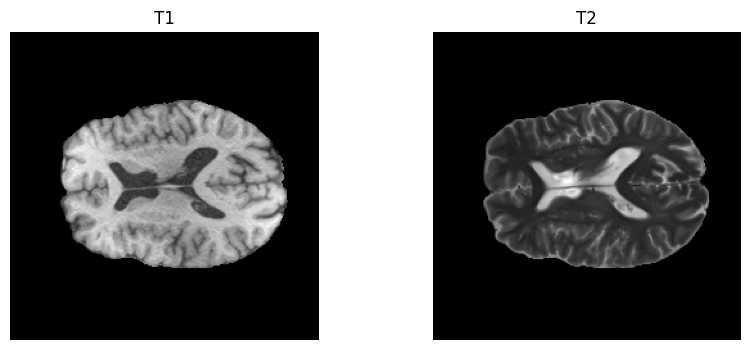

T1 shape: torch.Size([1, 1, 240, 240, 155])
T2 shape: torch.Size([1, 1, 240, 240, 155])


In [14]:
#visualize one sample
batch = next(iter(train_loader))
t1 = batch["t1"][0, 0].cpu().numpy()
t2 = batch["t2"][0, 0].cpu().numpy()

z = t1.shape[2] // 2

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(t1[:, :, z], cmap="gray")
plt.title("T1")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(t2[:, :, z], cmap="gray")
plt.title("T2")
plt.axis("off")
plt.show()

print("T1 shape:", batch["t1"].shape)
print("T2 shape:", batch["t2"].shape)

In [ ]:
autoencoder = AutoencoderKL(
    spatial_dims=3,
    in_channels=1,
    out_channels=1,
    num_channels=(32, 64, 64),
    latent_channels=latent_channels,
    num_res_blocks=1,
    norm_num_groups=16,
    attention_levels=(False, False, True),
).to(device)

print(autoencoder)

In [ ]:
def kl_loss_fn(z_mu, z_sigma):
    kl = 0.5 * torch.sum(
        z_mu.pow(2) + z_sigma.pow(2) - torch.log(z_sigma.pow(2) + 1e-8) - 1,
        dim=[1, 2, 3, 4],
    )
    return torch.mean(kl)

ae_optimizer = torch.optim.Adam(autoencoder.parameters(), lr=ae_lr)

recon_weight = 1.0
kl_weight = 1e-6

In [ ]:
best_ae_loss = float("inf")

for epoch in range(ae_epochs):
    autoencoder.train()
    running_loss = 0.0

    pbar = tqdm(train_loader, desc=f"AE Epoch {epoch+1}/{ae_epochs}")
    for batch in pbar:
        t1 = batch["t1"].to(device)
        t2 = batch["t2"].to(device)

        # shared latent space across both modalities
        imgs = torch.cat([t1, t2], dim=0)

        ae_optimizer.zero_grad()

        recon, z_mu, z_sigma = autoencoder(imgs)
        recon_loss = F.l1_loss(recon, imgs)
        kl_loss = kl_loss_fn(z_mu, z_sigma)

        loss = recon_weight * recon_loss + kl_weight * kl_loss
        loss.backward()
        ae_optimizer.step()

        running_loss += loss.item()
        pbar.set_postfix({
            "loss": running_loss / (pbar.n + 1),
            "recon": recon_loss.item(),
            "kl": kl_loss.item(),
        })

    epoch_loss = running_loss / len(train_loader)
    print(f"[AE] Epoch {epoch+1}: {epoch_loss:.6f}")

    if epoch_loss < best_ae_loss:
        best_ae_loss = epoch_loss
        torch.save(autoencoder.state_dict(), output_dir / "best_autoencoder.pt")
        print("Saved best autoencoder")

In [ ]:
diffusion_model = DiffusionModelUNet(
    spatial_dims=3,
    in_channels=latent_channels * 2,   # noisy target latent + condition latent
    out_channels=latent_channels,      # predict noise for target latent
    num_channels=(64, 128, 128),
    attention_levels=(False, True, True),
    num_res_blocks=1,
    norm_num_groups=16,
    num_head_channels=(0, 32, 32),
).to(device)

scheduler = DDPMScheduler(
    num_train_timesteps=num_train_timesteps,
    schedule="linear_beta",
    beta_start=0.0015,
    beta_end=0.0195,
)

diff_optimizer = torch.optim.Adam(diffusion_model.parameters(), lr=diff_lr)

print(diffusion_model)

In [ ]:
best_diff_loss = float("inf")

for epoch in range(diff_epochs):
    diffusion_model.train()
    autoencoder.eval()

    running_loss = 0.0
    pbar = tqdm(train_loader, desc=f"Diff Epoch {epoch+1}/{diff_epochs}")

    for batch in pbar:
        t1 = batch["t1"].to(device)
        t2 = batch["t2"].to(device)

        with torch.no_grad():
            z_t1 = autoencoder.encode_stage_2_inputs(t1) * scale_factor
            z_t2 = autoencoder.encode_stage_2_inputs(t2) * scale_factor

        noise = torch.randn_like(z_t2)
        timesteps = torch.randint(
            0, scheduler.num_train_timesteps, (z_t2.shape[0],), device=device
        ).long()

        noisy_z_t2 = scheduler.add_noise(
            original_samples=z_t2,
            noise=noise,
            timesteps=timesteps
        )

        model_input = torch.cat([noisy_z_t2, z_t1], dim=1)

        diff_optimizer.zero_grad()
        noise_pred = diffusion_model(x=model_input, timesteps=timesteps)
        loss = F.mse_loss(noise_pred.float(), noise.float())

        loss.backward()
        diff_optimizer.step()

        running_loss += loss.item()
        pbar.set_postfix({"loss": running_loss / (pbar.n + 1)})

    epoch_loss = running_loss / len(train_loader)
    print(f"[DIFF] Epoch {epoch+1}: {epoch_loss:.6f}")

    if epoch_loss < best_diff_loss:
        best_diff_loss = epoch_loss
        torch.save(diffusion_model.state_dict(), output_dir / "best_diffusion_model.pt")
        print("Saved best diffusion model")